<a href="https://colab.research.google.com/github/Neethu-Suman/PEECT413-MACHINE-LEARNING/blob/main/2_2_Linear_Regression_Example_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Linear Regression Example

This notebook demonstrates a machine learning workflow for predicting car selling prices. The key steps involved are:

1.  **Data Loading:** The car price dataset was downloaded from Kaggle and loaded into a pandas DataFrame.
2.  **Data Splitting:** The dataset was split into training and testing sets to prepare for model training and evaluation.
3.  **Feature Engineering (Mean Encoding):** Categorical features ('make' and 'model') were transformed using mean encoding based on the target variable ('selling_price') from the training data.
4.  **Handling Unseen Categories:** Unique categorical values present only in the test set (which were not encountered during training for mean encoding) were identified and removed from the test set, along with their corresponding target values, to maintain data consistency.
5.  **Feature Scaling (MinMax Scaling):** Numerical features in both training and testing sets were scaled using MinMaxScaler to normalize their ranges.
6.  **Model Training:** A Linear Regression model was initialized and trained on the preprocessed and scaled training data.
7.  **Model Interpretation:** The coefficients of the trained Linear Regression model were analyzed to understand the importance of each feature in predicting car selling prices. `model` was identified as the most important feature and `Manual` as the least important.

## Dataset Description

The dataset used in this notebook is sourced from Kaggle ('iyervenkatesh/cars24'). It contains information about used cars, primarily focusing on attributes relevant to predicting their selling price. Below is a description of the columns in the initial DataFrame `df`:

-   **selling_price**: The target variable, representing the selling price of the car (in lakhs INR).
-   **year**: The manufacturing year of the car.
-   **km_driven**: The total kilometers driven by the car.
-   **mileage**: The fuel efficiency of the car (kmpl or km/kg).
-   **engine**: The engine displacement of the car (in CC).
-   **max_power**: The maximum power produced by the car's engine (in bhp).
-   **age**: The age of the car (in years).
-   **make**: The brand or manufacturer of the car.
-   **model**: The specific model name of the car.
-   **Individual**: A binary indicator (1 if sold by an individual, 0 otherwise).
-   **Trustmark Dealer**: A binary indicator (1 if sold by a Trustmark Dealer, 0 otherwise).
-   **Diesel**: A binary indicator (1 if the fuel type is Diesel, 0 otherwise).
-   **Electric**: A binary indicator (1 if the fuel type is Electric, 0 otherwise).
-   **LPG**: A binary indicator (1 if the fuel type is LPG, 0 otherwise).
-   **Petrol**: A binary indicator (1 if the fuel type is Petrol, 0 otherwise).
-   **Manual**: A binary indicator (1 if the transmission type is Manual, 0 otherwise).
-   **5**: A binary indicator (1 if the number of seats is 5, 0 otherwise).
-   **>5**: A binary indicator (1 if the number of seats is greater than 5, 0 otherwise).

In [ ]:
# Import the numpy library for numerical operations
import numpy as np
# Import the pandas library for data manipulation and analysis
import pandas as pd
# Import the matplotlib.pyplot library for creating static, interactive, and animated visualizations
import matplotlib.pyplot as plt

In [ ]:
# Import the kagglehub library to interact with Kaggle datasets
import kagglehub

# Download the latest version of the specified Kaggle dataset
path = kagglehub.dataset_download("iyervenkatesh/cars24")

# Print the path where the dataset files are located
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cars24' dataset.
Path to dataset files: /kaggle/input/cars24


In [ ]:
# Import the os module for interacting with the operating system, like joining paths
import os
# Define the name of the CSV file containing the car data
file_name = 'cars24-car-price-cleaned.csv'
# Construct the full file path by joining the downloaded dataset path and the file name
full_file_path = os.path.join(path, file_name)
# Read the CSV file into a pandas DataFrame
df = pd.read_csv(full_file_path)
# Display the first few rows of the DataFrame to inspect the data
df.head()

,selling_price,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,1.20,2012.0,120000,19.70,796.0,46.30,11.0,MARUTI,ALTO STD,1,0,0,0,0,1,1,1,0
1,5.50,2016.0,20000,18.90,1197.0,82.00,7.0,HYUNDAI,GRAND I10 ASTA,1,0,0,0,0,1,1,1,0
2,2.15,2010.0,60000,17.00,1197.0,80.00,13.0,HYUNDAI,I20 ASTA,1,0,0,0,0,1,1,1,0
3,2.26,2012.0,37000,20.92,998.0,67.10,11.0,MARUTI,ALTO K10 2010-2014 VXI,1,0,0,0,0,1,1,1,0
4,5.70,2015.0,30000,22.77,1498.0,98.59,8.0,FORD,ECOSPORT 2015-2021 1.5 TDCI TITANIUM BSIV,0,0,1,0,0,0,1,1,0


In [ ]:
# Assign the 'selling_price' column as the target variable (y)
y = df['selling_price']
# Create the feature matrix (X) by dropping the 'selling_price' column from the DataFrame
X = df.drop('selling_price', axis=1)
# Print the shapes of the target variable and feature matrix to verify dimensions
y.shape, X.shape

((19820,), (19820, 17))

In [ ]:
# Import the train_test_split function from sklearn.model_selection for splitting data
from sklearn.model_selection import train_test_split
# Split the data into training and testing sets (70% train, 30% test) with a fixed random state
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

## PreProcessing

### Encoding

We will preprocess our data after splitting.

**Note:** We don't split the data after preprocessing to prevent Data Leakage.
More on this in the later lectures.

### Target Variable Encoding

Creating a dictionary from training data for mean encoding

In [ ]:
# Add the target variable (y_train) as a new column named 'target' to the training features (X_train)
X_train['target']=y_train

In [ ]:
# Calculate the mean 'target' (selling_price) for each 'make' and convert it to a dictionary
make_dict = X_train.groupby('make')['target'].mean().to_dict()
# Calculate the mean 'target' (selling_price) for each 'model' and convert it to a dictionary
model_dict = X_train.groupby('model')['target'].mean().to_dict()

In [ ]:

model_dict

{'1 SERIES 118D SPORT LINE': 12.825,
 '1 SERIES 118D SPORT PLUS': 9.85,
 '1.4GSI': 1.5166666666666666,
 '3 SERIES 316I': 10.0,
 '3 SERIES 320D': 12.617678571428561,
 '3 SERIES 320D CORPORATE EDITION': 9.777777777777779,
 '3 SERIES 320D DYNAMIC': 9.95,
 '3 SERIES 320D GT LUXURY LINE': 20.90249999999996,
 '3 SERIES 320D HIGHLINE': 9.235714285714286,
 '3 SERIES 320D LUXURY LINE': 18.2273611111111,
 '3 SERIES 320D LUXURY LINE PLUS': 20.90249999999996,
 '3 SERIES 320D LUXURY PLUS': 11.375,
 '3 SERIES 320D M SPORT': 19.90124999999998,
 '3 SERIES 320D PRESTIGE': 13.300227272727268,
 '3 SERIES 320D SEDAN': 9.11,
 '3 SERIES 320D SPORT': 19.67687499999997,
 '3 SERIES 320D SPORT LINE': 17.48687499999999,
 '3 SERIES 320I': 6.975,
 '3 SERIES 320I LUXURY LINE': 20.90249999999996,
 '3 SERIES 320SI SEDAN': 6.5,
 '3 SERIES 325I': 6.5,
 '3 SERIES 328I SPORT LINE': 18.0,
 '3 SERIES 330I SPORT LINE': 20.90249999999996,
 '3 SERIES GT 320D LUXURY LINE': 20.308333333333305,
 '3 SERIES GT 320D SPORT LINE': 20

In [ ]:
# Drop the temporarily added 'target' column from the training features DataFrame X_train
X_train.drop('target', axis=1, inplace=True)

In [ ]:
# Replace 'model' categorical values in X_train with their mean encoded numerical values using model_dict
X_train['model']=X_train['model'].replace(model_dict)
# Replace 'make' categorical values in X_train with their mean encoded numerical values using make_dict
X_train['make']=X_train['make'].replace(make_dict)

/tmp/ipython-input-2560408797.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train['model']=X_train['model'].replace(model_dict)
/tmp/ipython-input-2560408797.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train['make']=X_train['make'].replace(make_dict)


In [ ]:
X_train['model']

,model
9637,3.201765
4266,20.902500
6483,7.500000
10024,5.541429
7122,4.466667
...,...
10955,4.791667
17289,5.245333
5192,3.182679
12172,4.958333


In [ ]:
# Replace 'model' categorical values in X_test with their mean encoded numerical values using model_dict
X_test['model']=X_test['model'].replace(model_dict)
# Replace 'make' categorical values in X_test with their mean encoded numerical values using make_dict
X_test['make']=X_test['make'].replace(make_dict)

In [ ]:
# Display the first few rows of the preprocessed X_test DataFrame
X_test.head()

,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
14690,2009.0,70000,17.00,1086.0,5.0,14.0,5.437345,SANTRO XING GL PLUS CNG,1,0,0,0,0,0,1,1,0
134,2015.0,58000,25.20,1248.0,74.0,8.0,4.68396,4.69931,0,0,1,0,0,0,1,1,0
4982,2017.0,50000,25.32,1198.0,77.0,6.0,7.320377,6.0,0,0,1,0,0,0,1,0,1
11940,2010.0,72000,16.80,1497.0,118.0,13.0,5.949517,3.53,0,0,0,0,0,1,0,1,0
10861,2015.0,70000,26.59,1248.0,74.0,8.0,4.68396,5.261472,1,0,1,0,0,0,1,1,0


As we notice, there are some unique values in model, which aren't encoded.

If we further analyze, we will realize these are values with only a single occurence in the data.

In [ ]:
# Identify unique 'model' values in X_test that were not successfully converted to numeric (i.e., not encoded)
uniq_val_model = X_test[pd.to_numeric(X_test['model'], errors='coerce').isnull()]['model'].unique()
# Identify unique 'make' values in X_test that were not successfully converted to numeric (i.e., not encoded)
uniq_val_make = X_test[pd.to_numeric(X_test['make'], errors='coerce').isnull()]['make'].unique()

In [ ]:
# Print the number of unique, unencoded 'model' values and 'make' values found in X_test
print(len(uniq_val_model), len(uniq_val_make))

390 3


In [ ]:
# Print the shape of the X_test DataFrame (number of rows, number of columns)
X_test.shape

(5946, 17)

Since there are 390 our of 5946 (<7%) rows with such values, we will just go ahead and drop them.

In [ ]:
# Add the target variable (y_test) as a new column named 'selling_price' to the test features (X_test)
X_test['selling_price']=y_test

We also have to drop the corresponsing rows in target variable y_test

In [ ]:
# Drop rows from X_test where the 'model' is one of the unique, unencoded values identified earlier
X_test.drop(X_test.loc[X_test['model'].isin(uniq_val_model)].index, inplace=True)
# Drop rows from X_test where the 'make' is one of the unique, unencoded values identified earlier
X_test.drop(X_test.loc[X_test['make'].isin(uniq_val_model)].index, inplace=True)

In [ ]:
# Reassign y_test with the 'selling_price' column from the modified X_test DataFrame
y_test = X_test['selling_price']
# Drop the 'selling_price' column from X_test, as it's now the target variable
X_test.drop('selling_price', axis=1, inplace=True)

### MinMax Scaling

In [ ]:
# Import the MinMaxScaler from sklearn.preprocessing for feature scaling
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler = MinMaxScaler()
# Fit the scaler to the training data (X_train) to learn the scaling parameters
scaler.fit(X_train)

# Transform X_train using the fitted scaler and convert the result back to a DataFrame with original column names
X_train=pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)
# Transform X_test using the fitted scaler and convert the result back to a DataFrame with original column names
X_test=pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [ ]:
# Import the LinearRegression model from sklearn.linear_model
from sklearn.linear_model import LinearRegression
# Initialize a Linear Regression model
model = LinearRegression()
# Train the Linear Regression model using the scaled training data
model.fit(X_train, y_train)

LinearRegression()

### Understanding our model

In [ ]:
# Display the coefficients learned by the Linear Regression model
model.coef_

array([ 2.14306218, -4.71057125, -4.68059256,  1.3377762 ,  0.84509313,
       -2.14306218,  1.29641758, 17.88442049, -0.14268923, -0.13938682,
        0.11076569,  2.74816552,  0.29897844, -0.14519975, -0.0808793 ,
       -0.27055329, -0.41622693])

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
 [Text(0, 0, 'year'),
  Text(1, 0, 'km_driven'),
  Text(2, 0, 'mileage'),
  Text(3, 0, 'engine'),
  Text(4, 0, 'max_power'),
  Text(5, 0, 'age'),
  Text(6, 0, 'make'),
  Text(7, 0, 'model'),
  Text(8, 0, 'Individual'),
  Text(9, 0, 'Trustmark Dealer'),
  Text(10, 0, 'Diesel'),
  Text(11, 0, 'Electric'),
  Text(12, 0, 'LPG'),
  Text(13, 0, 'Petrol'),
  Text(14, 0, 'Manual'),
  Text(15, 0, '5'),
  Text(16, 0, '>5')])

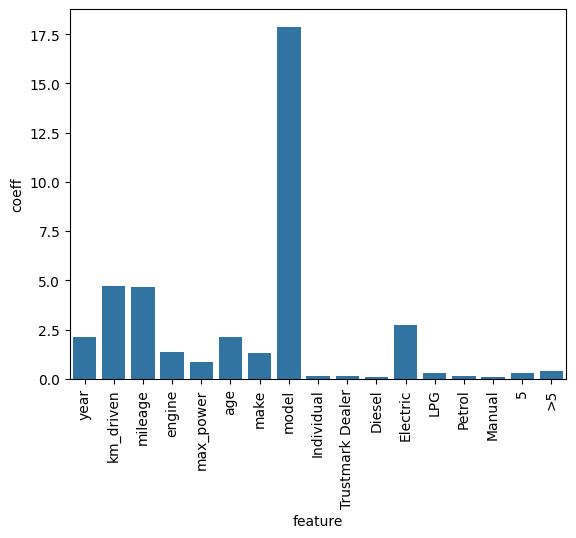

In [ ]:
# Import the seaborn library for statistical data visualization
import seaborn as sns

# Create a DataFrame 'imp' to store feature names and the absolute values of their coefficients
imp = pd.DataFrame(list(zip(X_test.columns,np.abs(model.coef_))),
                   columns=['feature', 'coeff'])
# Create a bar plot using seaborn to visualize the coefficients of each feature
sns.barplot(x='feature', y='coeff', data=imp)
# Rotate x-axis labels by 90 degrees for better readability, especially with many features
plt.xticks(rotation=90)

In [ ]:
# Find the feature name corresponding to the largest absolute coefficient value in the model
X_test.columns[np.argmax(np.abs(model.coef_))]

'model'

In [ ]:
# Find the feature name corresponding to the smallest absolute coefficient value in the model
X_test.columns[np.argmin(np.abs(model.coef_))]

'Manual'

So,
- `year` is most important feature,
- while `manual` is the least important.

In [ ]:
# Calculate the R2 score of the trained model on the test data
r2_score = model.score(X_test, y_test)
# Print the calculated R2 score, formatted to two decimal places
print(f"R2 Score: {r2_score:.2f}")

R2 Score: 0.91


## R2 Score Summary

The R2 score obtained is **0.91**. This indicates that the linear regression model explains approximately 91% of the variance in the car selling prices. An R2 score of 0.91 suggests a strong fit, meaning the model is quite effective at predicting the selling price based on the given features. A higher R2 score (closer to 1) generally implies a better fit of the model to the data.